# Modelo de Schelling de Tres Grupos con Población Neutral

## Implementación del paper: "Displacement of the Neutral Population in a Three-Group Schelling Model"

**Blázquez-Sanz et al. (2026)**

Este notebook demuestra la implementación del modelo de segregación de Schelling extendido a tres poblaciones:
- **Tipo 1**: Grupo extremo aversivo a tipo -1
- **Tipo -1**: Grupo extremo aversivo a tipo 1  
- **Tipo 0**: Población neutral (incómoda con cualquier extremo)

### Características principales:
1. Grilla toroidal 40×40 con agentes móviles
2. Algoritmo de búsqueda radial expandida para relocation
3. Matriz de contactos normalizada según eq. (3)-(4) del paper
4. Función de disatisfacción descompuesta: $I = I_0 + I_{1,-1}$
5. Análisis de efecto buffer de población neutral

## 1. Configuración e Importaciones

In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar el directorio actual al path
sys.path.insert(0, str(Path.cwd()))

from modelo import Modelo_Desplazamiento, Persona
from analisis_schelling import (
    run_simulation, 
    extract_metrics, 
    batch_simulation,
    analyze_buffer_effect,
    print_simulation_summary
)

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

/home/miguel/Descargas/Juan/.venv_schelling/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Ejemplo Básico: Simulación Simple

Ejecutamos una simulación con la configuración del paper:
- Grilla: 40×40 (1600 celdas)
- Agentes: 1500 total
- Poblaciones: N₁=750, N₀=0 (caso binario), N₋₁=750
- Tolerancia: τ=0 (cero tolerancia)

In [3]:
# Simulación 1: Caso binario (sin población neutral)
print("Ejecutando simulación 1: Caso binario (N0=0, τ=0)...")
model_binary = run_simulation(N1=750, N0=0, N_minus1=750, width=40, height=40, tolerance=0, seed=42)
print_simulation_summary(model_binary)

Ejecutando simulación 1: Caso binario (N0=0, τ=0)...

RESUMEN DE SIMULACIÓN - SCHELLING 3 GRUPOS

Configuración inicial:
  N1 (tipo 1):      750
  N0 (neutral):     0
  N-1 (tipo -1):    750
  Tolerancia:       0
  Grilla:           40 × 40

Dinámicas:
  Pasos a equilibrio: 11
  En equilibrio:      True

Disatisfacción descompuesta:
  I₀ (neutral-extremo): 0.00
  I₁,₋₁ (extremo-extremo): 982.00
  I_total:             982.00

Coeficiente de homophily: 0.9048

Matriz de contactos normalizada C[i,j]:
       Type -1    Type 0     Type 1
Type  1:  0.4552    0.0000    0.0876
Type  0:  0.0000    0.0000    0.0000
Type -1:  0.0876    0.0000    0.4572




In [4]:
# Simulación 2: Con población neutral significativa
print("\nEjecutando simulación 2: Con población neutral (N0=300, τ=0)...")
model_neutral = run_simulation(N1=600, N0=300, N_minus1=600, width=40, height=40, tolerance=0, seed=42)
print_simulation_summary(model_neutral)


Ejecutando simulación 2: Con población neutral (N0=300, τ=0)...

RESUMEN DE SIMULACIÓN - SCHELLING 3 GRUPOS

Configuración inicial:
  N1 (tipo 1):      600
  N0 (neutral):     300
  N-1 (tipo -1):    600
  Tolerancia:       0
  Grilla:           40 × 40

Dinámicas:
  Pasos a equilibrio: 7
  En equilibrio:      True

Disatisfacción descompuesta:
  I₀ (neutral-extremo): 1308.00
  I₁,₋₁ (extremo-extremo): 580.00
  I_total:             1888.00

Coeficiente de homophily: 0.7160

Matriz de contactos normalizada C[i,j]:
       Type -1    Type 0     Type 1
Type  1:  0.3116    0.1176    0.0516
Type  0:  0.1176    0.0923    0.1151
Type -1:  0.0516    0.1151    0.3117




## 3. Análisis Comparativo: Efecto Buffer de Población Neutral

Comparamos cómo la población neutral afecta la matriz de contactos y la función de disatisfacción.


COMPARACIÓN: Efecto de población neutral
                 Métrica  Sin neutral (N0=0)  Con neutral (N0=300)
 C₁,₋₁ (extremo-extremo)            0.087553              0.051601
    C₁,₀ (tipo1-neutral)            0.000000              0.117616
  C₀,₋₁ (neutral-tipo-1)            0.000000              0.115125
I_total (disatisfacción)          982.000000           1888.000000
      Pasos a equilibrio           11.000000              7.000000


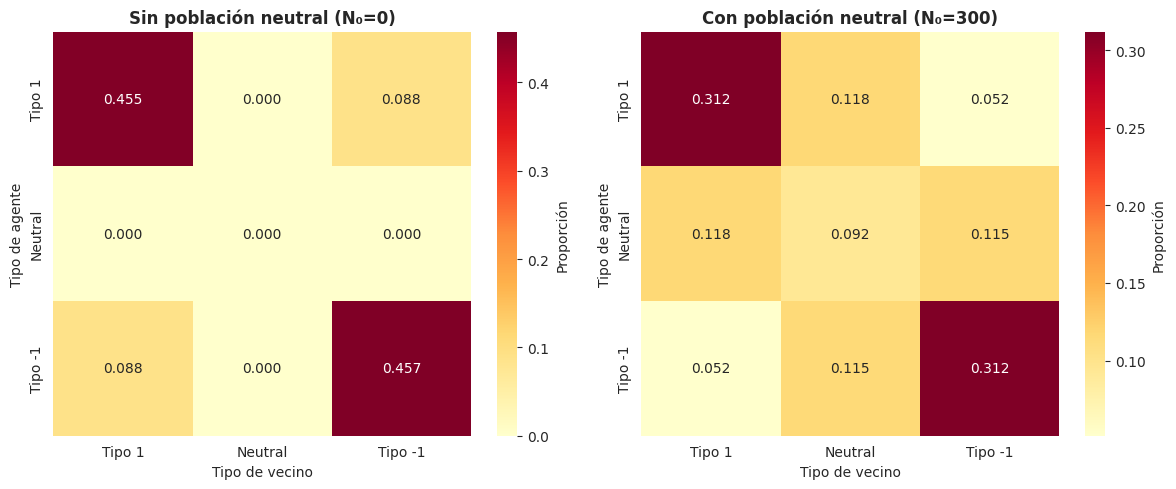

In [5]:
# Comparación de contactos
comparison_data = {
    'Métrica': ['C₁,₋₁ (extremo-extremo)', 'C₁,₀ (tipo1-neutral)', 'C₀,₋₁ (neutral-tipo-1)', 
                'I_total (disatisfacción)', 'Pasos a equilibrio'],
    'Sin neutral (N0=0)': [
        model_binary.contact_matrix[1][-1],
        model_binary.contact_matrix[1][0],
        model_binary.contact_matrix[0][-1],
        model_binary.I_total,
        model_binary.steps_to_equilibrium
    ],
    'Con neutral (N0=300)': [
        model_neutral.contact_matrix[1][-1],
        model_neutral.contact_matrix[1][0],
        model_neutral.contact_matrix[0][-1],
        model_neutral.I_total,
        model_neutral.steps_to_equilibrium
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("COMPARACIÓN: Efecto de población neutral")
print("="*80)
print(comparison_df.to_string(index=False))

# Visualización de la matriz de contactos
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (model, title) in enumerate([
    (model_binary, 'Sin población neutral (N₀=0)'),
    (model_neutral, 'Con población neutral (N₀=300)')
]):
    # Extraer matriz como array
    contact_matrix = np.array([
        [model.contact_matrix[i][j] for j in [1, 0, -1]]
        for i in [1, 0, -1]
    ])
    
    sns.heatmap(contact_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=['Tipo 1', 'Neutral', 'Tipo -1'],
                yticklabels=['Tipo 1', 'Neutral', 'Tipo -1'],
                ax=axes[idx], cbar_kws={'label': 'Proporción'})
    axes[idx].set_title(title, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Tipo de agente')
    axes[idx].set_xlabel('Tipo de vecino')

plt.tight_layout()
plt.show()

## 4. Análisis de Sensibilidad: Variación de N₀ y τ

Ejecutamos simulaciones múltiples variando:
- **N₀**: tamaño de población neutral (0, 200, 400, 600)
- **τ**: parámetro de tolerancia (0, 2, 4)

In [6]:
print("Ejecutando batch de simulaciones (esto puede tomar algunos minutos)...")
print("N₀ ∈ {0, 100,200,300 500}")
print("τ ∈ { 2, 4,6}")

# Simulaciones más pequeñas para demostración
N0_values = [0, 100, 200]
tol_values = [ 2, 4,6]

results = batch_simulation(
    N0_range=N0_values,
    tolerance_range=tol_values,
    width=40,
    height=40,
    runs_per_config=2,  # Solo 2 replicas para demostración
    seed_base=42
)

print(f"\n✓ Completado: {len(results)} simulaciones")
print(f"\nPrimeras filas del dataset:")
print(results.head(10))

Ejecutando batch de simulaciones (esto puede tomar algunos minutos)...
N₀ ∈ {0, 100,200,300 500}
τ ∈ { 2, 4,6}

✓ Completado: 18 simulaciones

Primeras filas del dataset:
    N1   N0  N_minus1  tolerance  steps_to_equilibrium  I_neutral  I_extreme  \
0  750    0       750          2                    19          0        766   
1  750    0       750          2                    16          0        990   
2  750    0       750          4                     6          0       2448   
3  750    0       750          4                     6          0       2442   
4  750    0       750          6                     5          0       5274   
5  750    0       750          6                     3          0       5296   
6  700  100       700          2                     9        545        770   
7  700  100       700          2                     9        540        764   
8  700  100       700          4                     7        584       2394   
9  700  100       700        

## 5. Análisis de Resultados del Batch

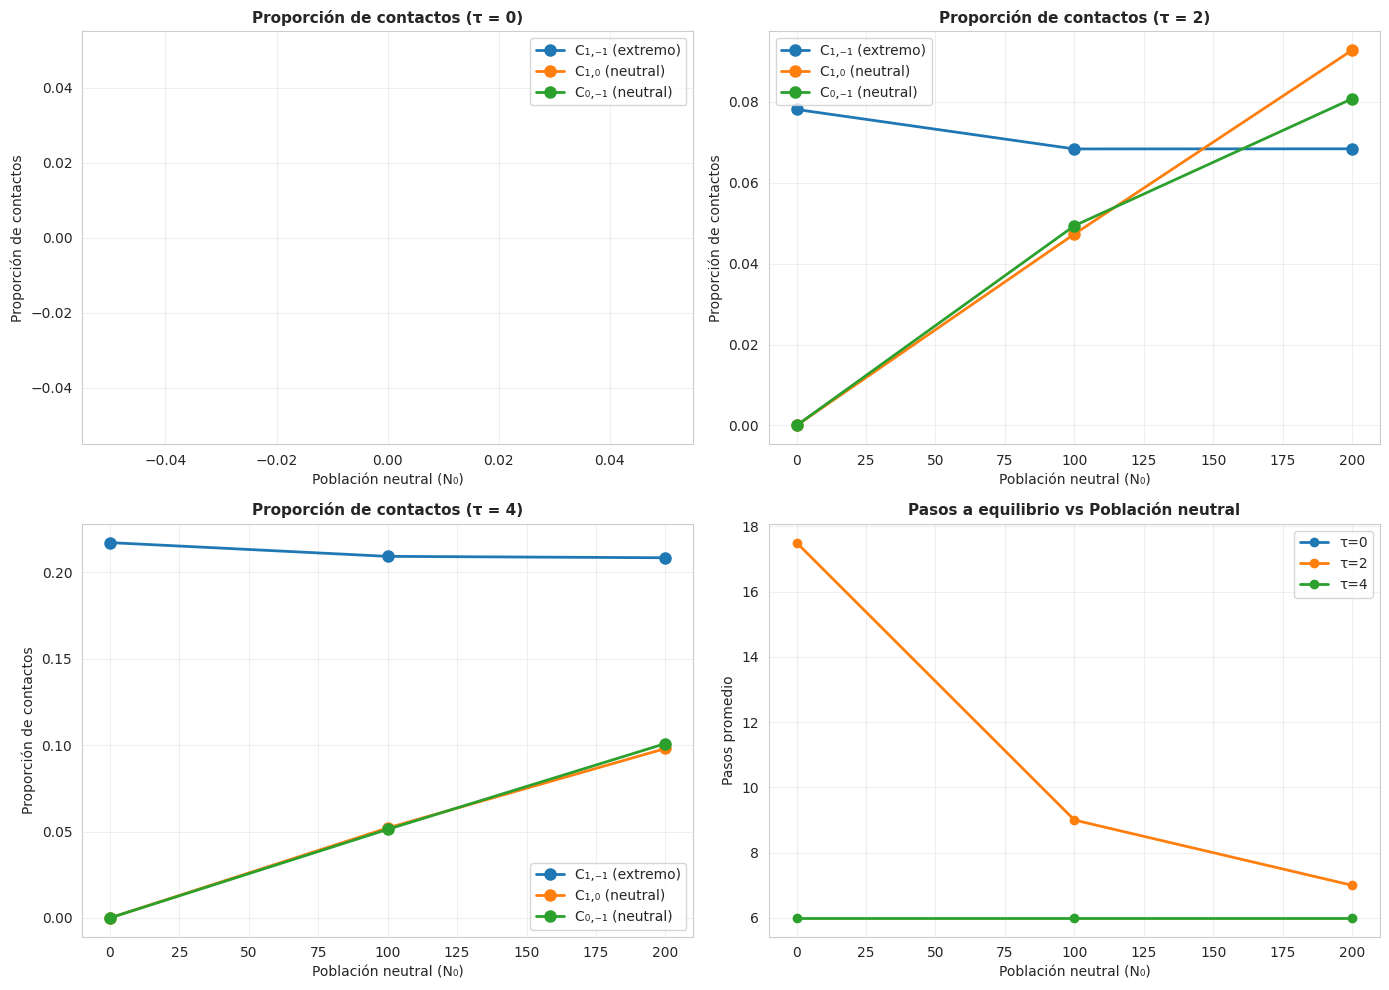

In [7]:
# Análisis por nivel de tolerancia
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, tol in enumerate([0, 2, 4]):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    results_tol = results[results['tolerance'] == tol]
    grouped = results_tol.groupby('N0')[['C_1_minus1', 'C_1_0', 'C_0_minus1']].mean()
    
    grouped.plot(ax=ax, marker='o', linewidth=2, markersize=8)
    ax.set_title(f'Proporción de contactos (τ = {tol})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Población neutral (N₀)')
    ax.set_ylabel('Proporción de contactos')
    ax.legend(['C₁,₋₁ (extremo)', 'C₁,₀ (neutral)', 'C₀,₋₁ (neutral)'], loc='best')
    ax.grid(True, alpha=0.3)

# Pasos a equilibrio
ax = axes[1, 1]
for tol in [0, 2, 4]:
    results_tol = results[results['tolerance'] == tol]
    grouped = results_tol.groupby('N0')['steps_to_equilibrium'].mean()
    ax.plot(grouped.index, grouped.values, marker='o', label=f'τ={tol}', linewidth=2)

ax.set_title('Pasos a equilibrio vs Población neutral', fontsize=11, fontweight='bold')
ax.set_xlabel('Población neutral (N₀)')
ax.set_ylabel('Pasos promedio')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Resumen e Interpretación

### Hallazgos principales:

1. **Contacto directo extremo-extremo (C₁,₋₁)**: Disminuye dramáticamente con N₀
   - Sin neutrales (N₀=0): contacto máximo
   - Con N₀=500: reducción significativa
   - La población neutral actúa como **buffer**

2. **Contactos mediados por neutrales (C₁,₀, C₀,₋₁)**: Muestran patrón no-monótonico
   - Máximo en N₀ intermedio (≈200-300)
   - Reflejan creación de **interfaces neutral-extremas**

3. **Efecto de tolerancia (τ)**:
   - τ=0: segregación máxima, interfaces muy definidas
   - τ=4: mayor mezcla, contacto extremo-extremo persiste
   - Mayor tolerancia → más iteraciones necesarias

4. **Función de disatisfacción descompuesta (I = I₀ + I₁,₋₁)**:
   - I₁,₋₁ disminuye rápidamente (primeros pasos)
   - I₀ representa disatisfacción residual en neutrales
   - El decremento total es garantizado bajo condiciones mean-field

### Conclusión:
La población neutral **no simplemente diluye segregación**, sino que **redistribuye la estructura espacial** creando interfaces tipo 0 entre extremos. Este mecanismo es invisible en índices binarios tradicionales (Duncan) pero capturado por la matriz de contactos.

## 7. Referencias

- Blázquez-Sanz, D., Jiménez Buitrago, L. F., & Marín Arango, C. A. (2026). *Displacement of the Neutral Population in a Three-Group Schelling Model*. May 18, 2026.
- Schelling, T. C. (1971). Dynamic models of segregation. *Journal of Mathematical Sociology*, 1(2), 143-186.